1. Import Libraries

In [10]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

import pickle
import os

2. Load Data

In [11]:
df = pd.read_csv("../data/processed_data.csv")

target_column = "productivity_score"

X = df[
[
'study_hours_per_day',
'focus_score',
'sleep_hours',
'attendance_percentage',
'stress_level',
'phone_usage_hours',
'social_media_hours'
]]

y = df[target_column]

3. Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

4. Scaling

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. Train Model

In [14]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


6. FEATURE IMPORTANCE

In [15]:
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coeff_df = coeff_df.sort_values(by="Coefficient", ascending=False)

coeff_df

,Feature,Coefficient
0,study_hours_per_day,11.839640
1,focus_score,6.544583
2,sleep_hours,5.483309
3,attendance_percentage,2.815769
6,social_media_hours,-0.000206
4,stress_level,-3.091757
5,phone_usage_hours,-5.347815


7. Feature Importance Graph

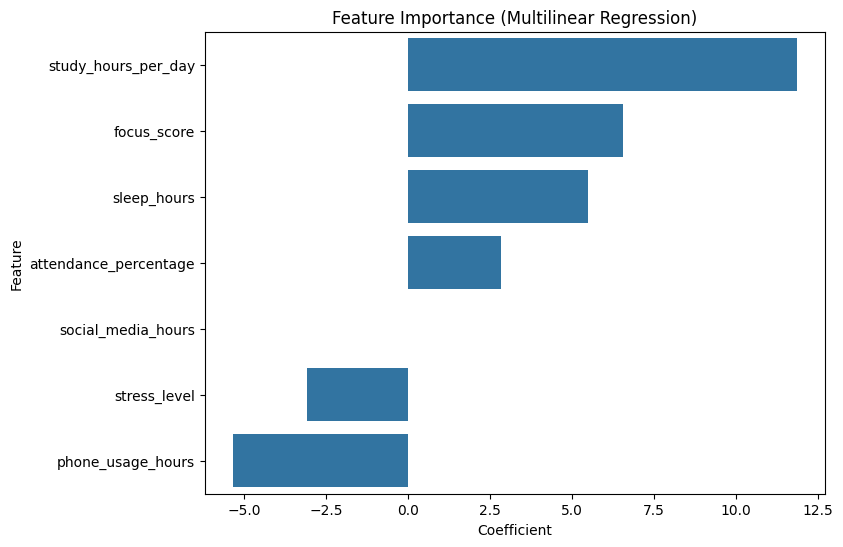

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.barplot(
    x="Coefficient",
    y="Feature",
    data=coeff_df
)
plt.title("Feature Importance (Multilinear Regression)")
plt.show()

8. Check Multicollinearity

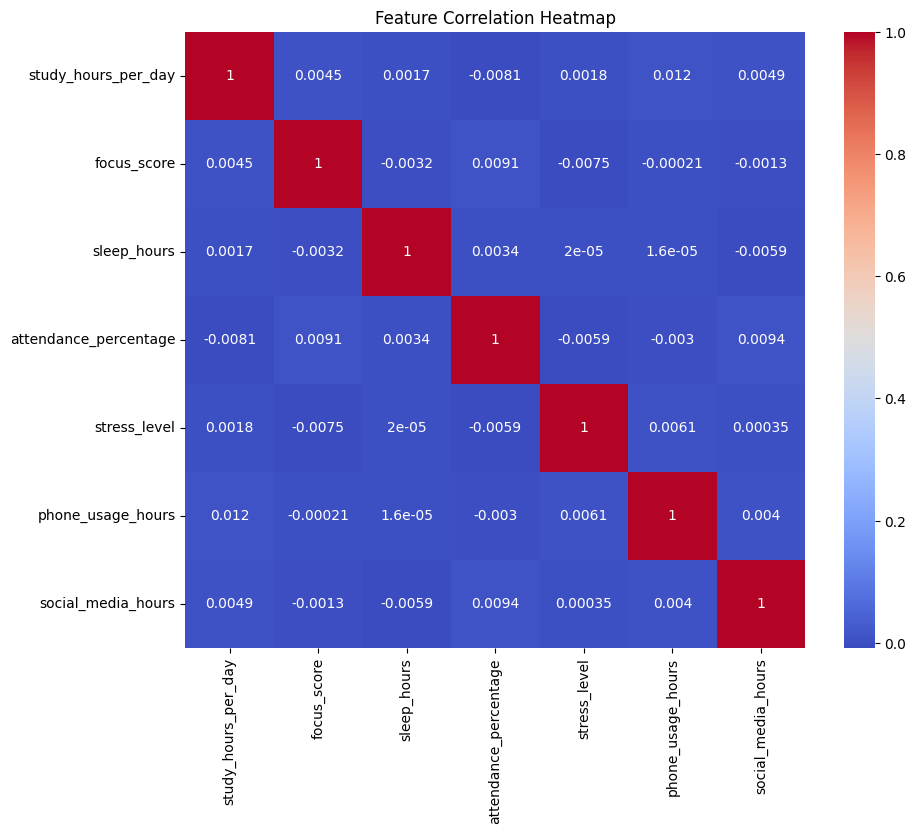

In [17]:
corr = X.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

9. Save Model

In [18]:
os.makedirs("../models/multilinear", exist_ok=True)

# Save model
with open("../models/multilinear/model.pkl", "wb") as f:
    pickle.dump(model, f)

# Save scaler
with open("../models/multilinear/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)